In [45]:
import numpy as np
import os
from ripser import ripser
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [46]:
# === Parameters ===
data_dir = "C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/rfMRI_ts/100206_REST1_dist/"
n_frames = 1081
start_frame, end_frame = 0, 500  # 원하는 구간으로 바꿔서 사용

# === Step 1: Load distance matrices ===
distance_matrices = []
for i in range(start_frame, end_frame):
    fname = os.path.join(data_dir, f"rs100206_dist_matrix_{i:03d}.txt")
    mat = np.loadtxt(fname)
    distance_matrices.append(mat)

In [47]:
len(distance_matrices)

500

In [48]:
distance_matrices[0].shape

(116, 116)

In [49]:
# === Step 2: Compute persistence diagrams (H0 & H1) ===
diagrams_H0, diagrams_H1 = [], []
for mat in distance_matrices:
    result = ripser(mat, maxdim=1, distance_matrix=True)
    diagrams_H0.append(result['dgms'][0])
    diagrams_H1.append(result['dgms'][1])

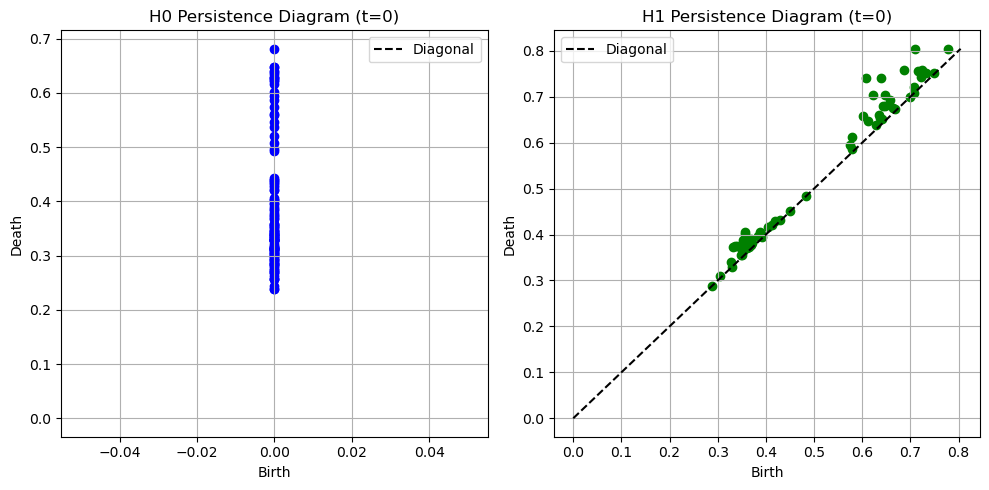

In [50]:
# === 시각화할 time step 지정 ===
sample_t = 0  # 0부터 시작

# === persistence diagram 가져오기 ===
dgm0 = diagrams_H0[sample_t]
dgm1 = diagrams_H1[sample_t]

# === 그림 그리기 ===
plt.figure(figsize=(10, 5))

# H0
plt.subplot(1, 2, 1)
plt.scatter(dgm0[:, 0], dgm0[:, 1], color='blue')
plt.plot([0, max(dgm0[:, 1])], [0, max(dgm0[:, 1])], 'k--', label='Diagonal')
plt.title(f'H0 Persistence Diagram (t={sample_t})')
plt.xlabel('Birth')
plt.ylabel('Death')
plt.grid(True)
plt.legend()

# H1
plt.subplot(1, 2, 2)
if len(dgm1) > 0:
    plt.scatter(dgm1[:, 0], dgm1[:, 1], color='green')
    plt.plot([0, max(dgm1[:, 1])], [0, max(dgm1[:, 1])], 'k--', label='Diagonal')
else:
    plt.text(0.5, 0.5, 'No H1 features', ha='center')
plt.title(f'H1 Persistence Diagram (t={sample_t})')
plt.xlabel('Birth')
plt.ylabel('Death')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [51]:
diagrams_H1[420].shape

(18, 2)

In [52]:
diagrams_H1[420][np.all(np.isfinite(diagrams_H1[420]), axis=1)].shape

(18, 2)

In [54]:
# === Step 3: Build vines with Hungarian matching ===
def build_vines(diagrams, frame_count):
    max_points = max(len(dgm) for dgm in diagrams)
    vines = [[] for _ in range(max_points)]

    for t in range(frame_count - 1):
        D1 = diagrams[t]
        D2 = diagrams[t + 1]
        if len(D1) == 0 or len(D2) == 0:
            continue
        
        D1[np.isinf(D1)] = 1.0
        D2[np.isinf(D2)] = 1.0

        m, n = len(D1), len(D2)

        if m == 0 or n == 0:
            continue
        cost_matrix = np.full((max(m, n), max(m, n)), 1e9)
        cost_matrix[:m, :n] = np.max(np.abs(D1[:, None, :] - D2[None, :, :]), axis=2)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        if t == 0:
            for i in range(len(row_ind)):
                if row_ind[i] < m and col_ind[i] < n:
                    vines[i].append((t, *D1[row_ind[i]]))
                    vines[i].append((t + 1, *D2[col_ind[i]]))
        else:
            for i in range(len(row_ind)):
                if row_ind[i] < m and col_ind[i] < n:
                    vines[i].append((t + 1, *D2[col_ind[i]]))
    return vines

vines_H0 = build_vines(diagrams_H0, len(distance_matrices))
vines_H1 = build_vines(diagrams_H1, len(distance_matrices))

In [58]:
vines_H1[130]

[(136, np.float64(0.5568280220031738), np.float64(0.5857040286064148)),
 (137, np.float64(0.6466339826583862), np.float64(0.7739989757537842)),
 (138, np.float64(0.6466500163078308), np.float64(0.6987450122833252)),
 (203, np.float64(0.5836700201034546), np.float64(0.594880998134613)),
 (204, np.float64(0.6399070024490356), np.float64(0.6433650255203247)),
 (205, np.float64(0.6454939842224121), np.float64(0.6657159924507141)),
 (206, np.float64(0.6050029993057251), np.float64(0.6302750110626221)),
 (218, np.float64(0.6254929900169373), np.float64(0.6310499906539917)),
 (219, np.float64(0.330500990152359), np.float64(0.33356499671936035))]

In [64]:
def vines_to_time_value(vines):
    """
    Given:
      vines: a list of vines, where each vine is a list of (t, birth, death) tuples.
    Returns:
      new_vines: a list of lists, where each sub-list is [(t, value), …],
                 and value = death - birth for each tuple.
    """
    new_vines = []
    for vine in vines:
        # If this vine is nonempty, convert each (t, b, d) → (t, d - b).
        if vine:
            tv_list = []
            for (t, birth, death) in vine:
                value = death - birth
                tv_list.append((t, value))
            new_vines.append(tv_list)
        else:
            # An empty vine stays empty
            new_vines.append([])
    return new_vines

# Example usage:
#   Suppose vines_H0 has shape [vine0, vine1, …], each vine_i = [(0,0,d0),(1,0,d1),…].
#   Then:
#     time_value_H0 = vines_to_time_value(vines_H0)
#   Each time_value_H0[i] will look like [(0, d0),(1, d1),…,(499, d499)].


# ——— If you also want to keep birth and death alongside value, use this version: ———
def vines_to_full_time_value(vines):
    """
    Given:
      vines: a list of vines, where each vine is a list of (t, birth, death) tuples.
    Returns:
      new_vines: a list of lists, where each sub-list is [(t, birth, death, value), …].
                 Here value = death - birth for each original tuple.
    """
    new_vines = []
    for vine in vines:
        if vine:
            full_list = []
            for (t, birth, death) in vine:
                value = death - birth
                full_list.append((t, birth, death, value))
            new_vines.append(full_list)
        else:
            new_vines.append([])
    return new_vines


In [69]:
# H0 / H1 점수 리스트
scores_H0 = vines_to_time_value(vines_H0)
scores_H1 = vines_to_time_value(vines_H1)

In [ ]:
# 정렬된 (index, score) 출력 (내림차순)
scores_H0_sorted = sorted(scores_H0, key=lambda x: x[1], reverse=True)
scores_H1_sorted = sorted(scores_H1, key=lambda x: x[1], reverse=True)

print("==== H0 Vine Scores (index, death_0) 내림차순 ====")
for idx, sc in scores_H0_sorted[:10]:
    print(f"vine_{idx}  score(H0 death_0) = {sc:.4f}")

print("\n==== H1 Vine Scores (index, persistence_0) 내림차순 ====")
for idx, sc in scores_H1_sorted[:10]:
    print(f"vine_{idx}  score(H1 persistence_0) = {sc:.4f}")

In [80]:
# === (4) Vine을 하나씩 2D 플롯으로 그리는 함수 ===
def plot_single_vine(vine, homology_dim, vine_idx):
    
    if not vine:
        print(f"vine_{vine_idx} is empty → skip plotting.")
        return

    times = [v[0] for v in vine]
    values = [v[1] for v in vine]
    
    plt.figure(figsize=(20, 4))
    if homology_dim == 0:
        # H0: death 값만 plot
        plt.plot(times, values, marker='o', linestyle='-', color='tab:blue')
        plt.ylabel('Persistence (H0)')
        title = f'H0 Vine #{vine_idx} (pers = {values[0]:.4f})'
    else:
        # H1: persistence = death - birth (time별)
        plt.plot(times, values, marker='o', linestyle='-', color='tab:orange')
        plt.ylabel('Persistence (H1)')
        title = f'H1 Vine #{vine_idx} (pers = {values[0]:.4f})'

    plt.xlabel('Time step')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [30]:
# === (5) Batch 단위로 vine 하나씩 보고 싶다면 ===
# 예를 들어, 한번에 1개씩 차례대로 보고 싶으면:
n_vines_H0 = len(vines_H0)
n_vines_H1 = len(vines_H1)



>>> Plotting all H0 vines (death 값 기준) <<<


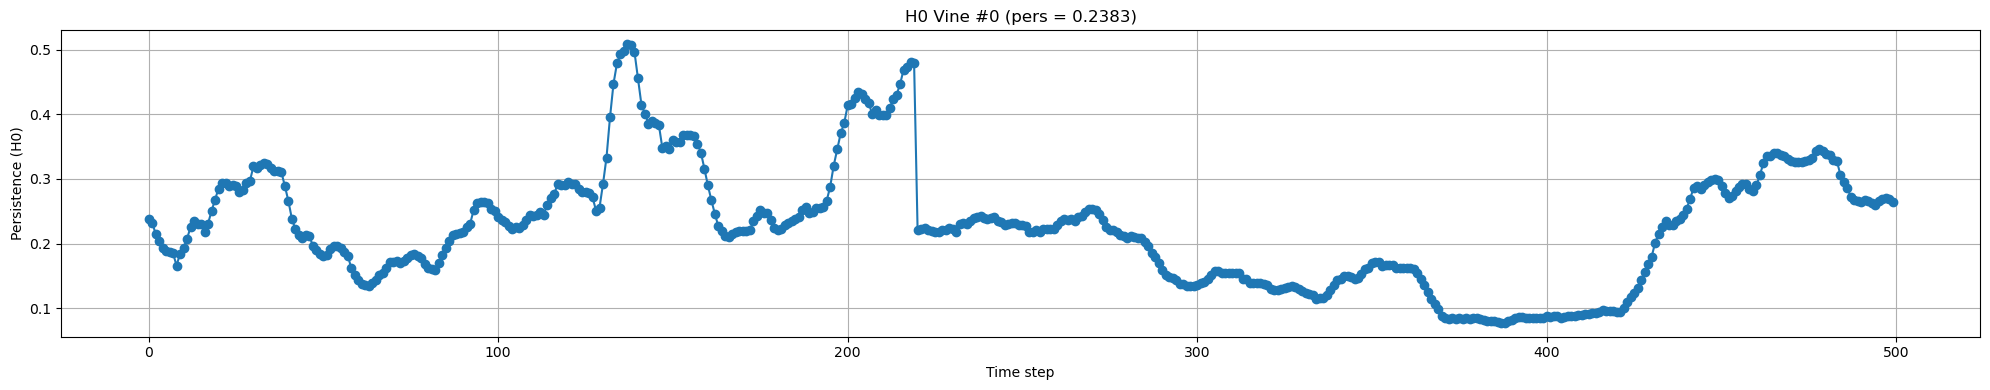

In [81]:
# H0 vine 모두 차례대로 그리기
print("\n>>> Plotting all H0 vines (death 값 기준) <<<")
for vine_idx in range(1):
    plot_single_vine(scores_H0[vine_idx], homology_dim=0, vine_idx=vine_idx)


>>> Plotting all H1 vines (persistence 값 기준) <<<


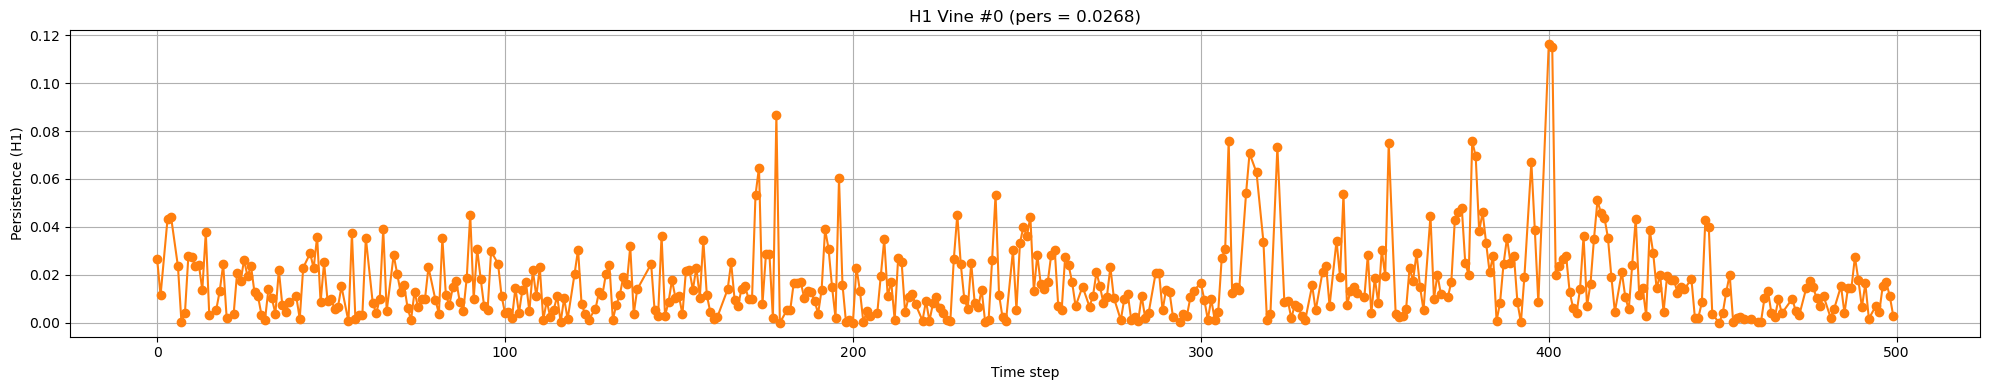

In [82]:
# H1 vine 모두 차례대로 그리기
print("\n>>> Plotting all H1 vines (persistence 값 기준) <<<")
for vine_idx in range(1):
    plot_single_vine(scores_H1[vine_idx], homology_dim=1, vine_idx=vine_idx)


In [ ]:
# --- 필요하다면 batch_size를 활용해 일정한 개수만 보고 싶은 경우: ---
# 예: H1 vine을 한 번에 5개씩
def plot_vine_batch(vines, homology_dim, start_idx=0, batch_size=5):
    end_idx = min(start_idx + batch_size, len(vines))
    for vine_idx in range(start_idx, end_idx):
        plot_single_vine(vines[vine_idx], homology_dim, vine_idx)


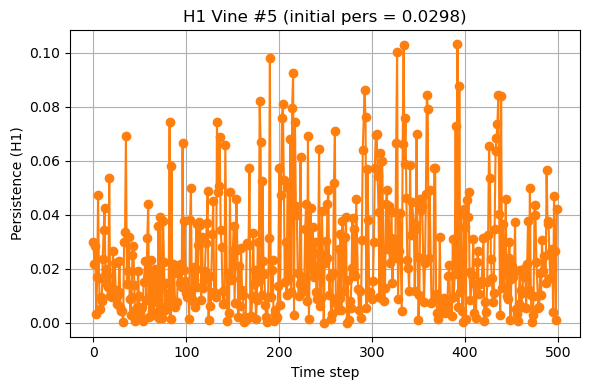

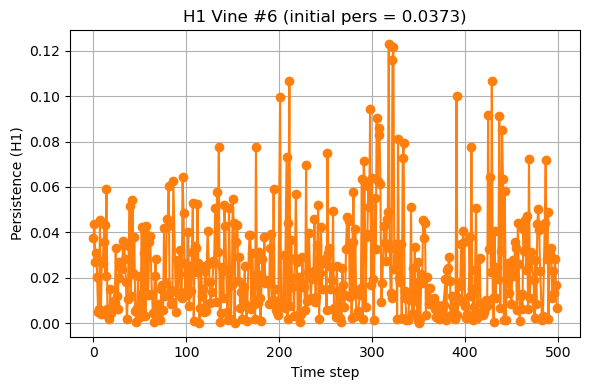

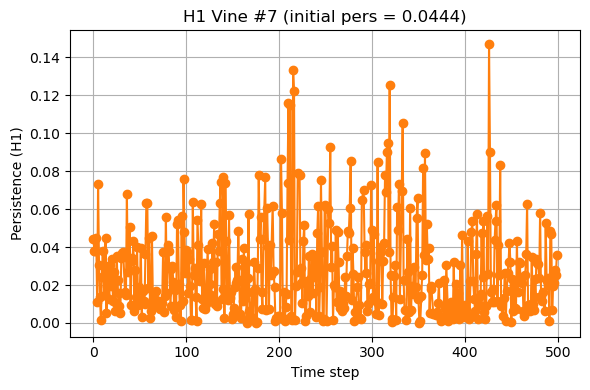

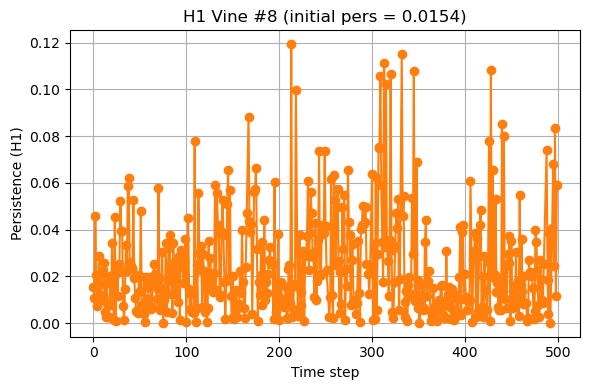

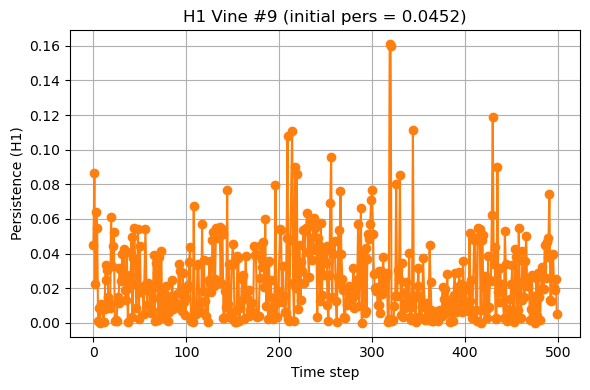

In [ ]:
plot_vine_batch(vines_H1, homology_dim=1, start_idx=5, batch_size=5)

In [ ]:
# === Step 4: Select top-5 vines by persistence at t=0 ===
def get_top_vine_ids(vines, top_k=5):
    vine_scores = []
    for i, vine in enumerate(vines):
        if vine:
            persistence = vine[0][2] - vine[0][1]
            vine_scores.append((i, persistence))
    top_ids = sorted(vine_scores, key=lambda x: x[1], reverse=True)[:top_k]
    return [vid[0] for vid in top_ids]

top5_H0_ids = get_top_vine_ids(vines_H0, top_k=5)
top5_H1_ids = get_top_vine_ids(vines_H1, top_k=5)

In [ ]:
# === Step 5: Plotting Functions ===
def plot_2d_vineyard(vines, vine_ids, title):
    plt.figure(figsize=(12, 6))
    for idx in vine_ids:
        vine = vines[idx]
        times = [v[0] for v in vine]
        births = [v[1] for v in vine]
        deaths = [v[2] for v in vine]
        plt.plot(times, births, linestyle='--', alpha=0.7, label=f'vine_{idx} birth')
        plt.plot(times, deaths, alpha=0.7, label=f'vine_{idx} death')
    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.title(title)
    plt.legend(loc='upper right', fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_3d_vineyard(vines, vine_ids, title):
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')
    for idx in vine_ids:
        vine = vines[idx]
        times = [v[0] for v in vine]
        births = [v[1] for v in vine]
        deaths = [v[2] for v in vine]
        ax.plot(times, births, deaths, label=f'vine_{idx}', alpha=0.8)
    ax.set_xlabel("Time")
    ax.set_ylabel("Birth")
    ax.set_zlabel("Death")
    ax.set_title(title)
    ax.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.show()

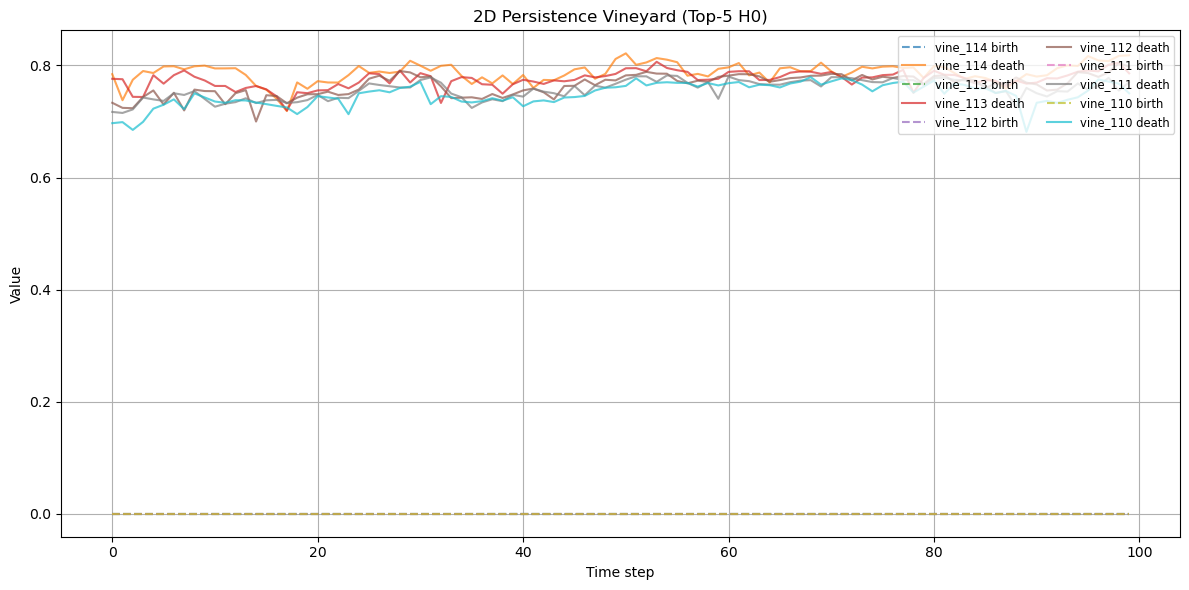

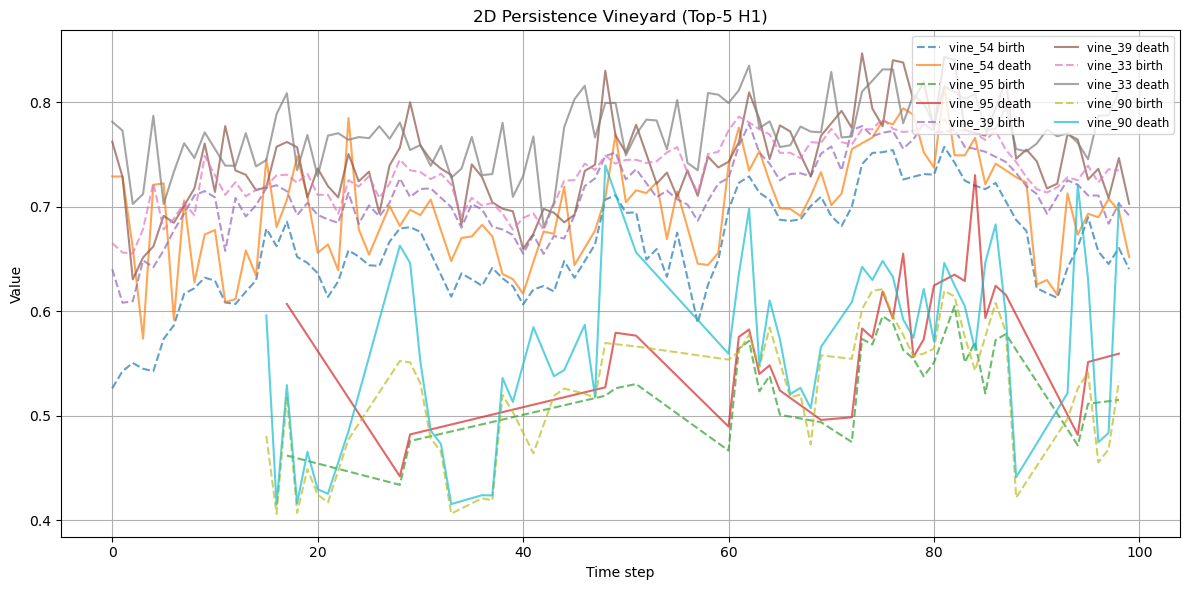

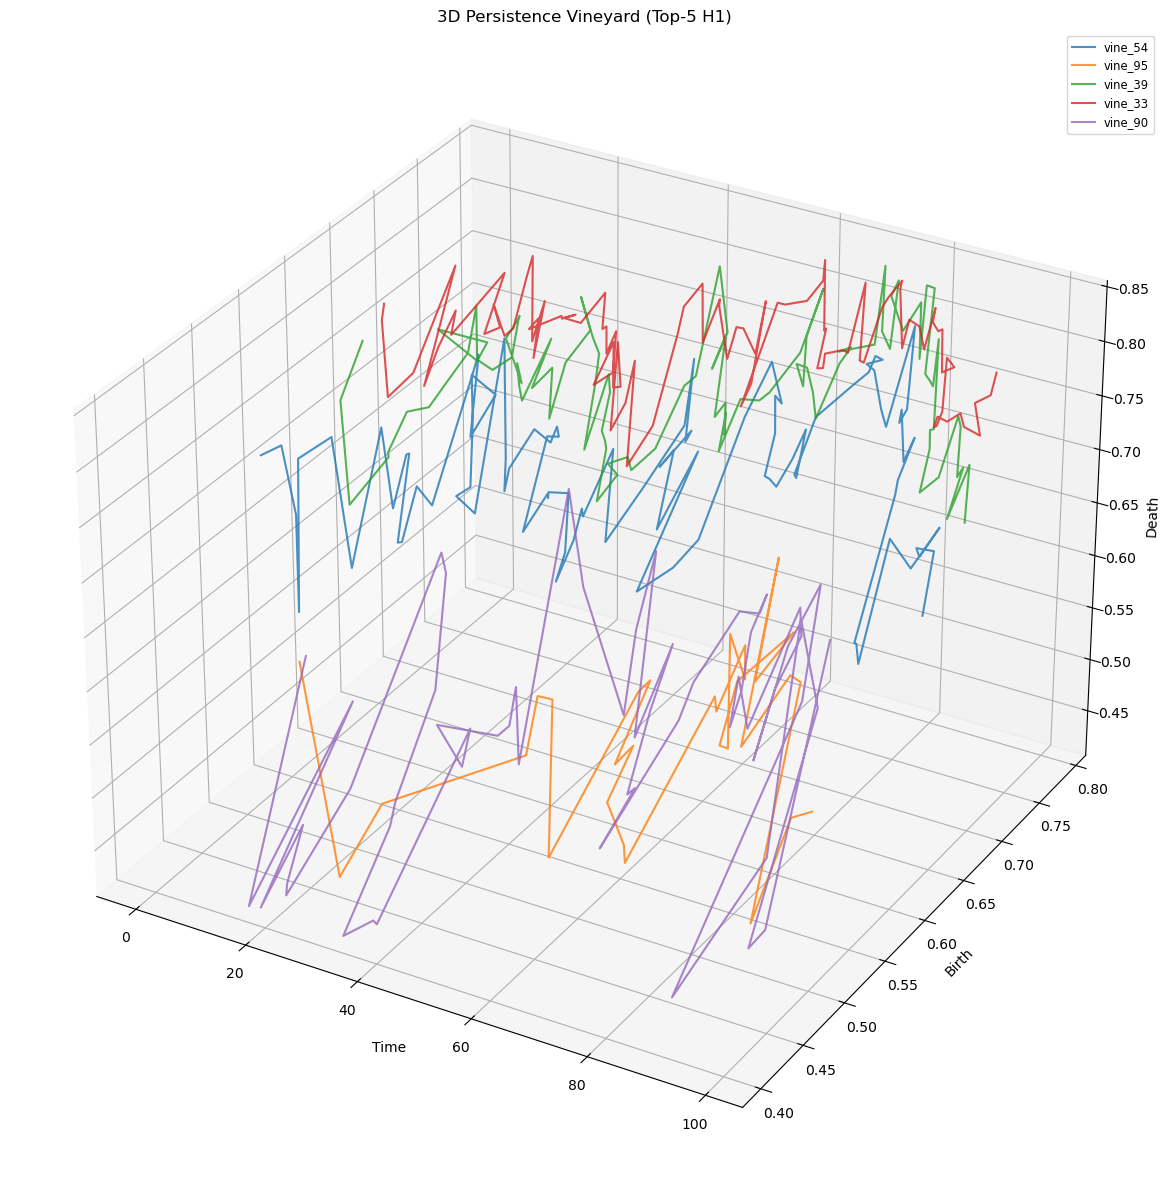

In [ ]:
# === Step 6: Visualize ===
plot_2d_vineyard(vines_H0, top5_H0_ids, "2D Persistence Vineyard (Top-5 H0)")
plot_2d_vineyard(vines_H1, top5_H1_ids, "2D Persistence Vineyard (Top-5 H1)")
plot_3d_vineyard(vines_H1, top5_H1_ids, "3D Persistence Vineyard (Top-5 H1)")

In [88]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection

def plot_vines_2d(time_value_vines, start_idx=0, end_idx=None):
    """
    Plot a 2D persistence vineyard for a specified range of vines.
    Each vine is given as a list of (time, value) tuples.
    Points are connected by line segments (no markers).

    Parameters:
    -----------
    time_value_vines : list of lists of tuples
        E.g., time_value_vines[i] = [(t0, v0), (t1, v1), …].

    start_idx : int, default=0
        First vine index to plot (inclusive).

    end_idx : int or None, default=None
        Last vine index to plot (inclusive). If None, plots to the end.
    """
    n_vines = len(time_value_vines)
    if end_idx is None or end_idx >= n_vines:
        end_idx = n_vines - 1

    plt.figure(figsize=(10, 6))
    cmap = plt.get_cmap('tab10')

    for idx in range(start_idx, end_idx + 1):
        vine = time_value_vines[idx]
        if not vine:
            continue  # skip empty vines

        times, values = zip(*vine)
        color = cmap((idx - start_idx) % 10)
        plt.plot(times, values, linestyle='-', color=color, label=f'vine_{idx}')

    plt.xlabel('Time Index')
    plt.ylabel('Value (death - birth)')
    plt.title(f'2D Persistence Vines (indices {start_idx} to {end_idx})')
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()


def plot_vines_3d(vines, start_idx=0, end_idx=None):
    """
    Plot a 3D persistence vineyard for a specified range of vines.
    Each vine is a list of (time, birth, death) tuples.
    Points are connected by line segments (no markers).

    Axes: 
      - x-axis: birth
      - y-axis: death
      - z-axis: time

    Parameters:
    -----------
    vines : list of lists of tuples
        E.g., vines[i] = [ (t0, b0, d0), (t1, b1, d1), … ].

    start_idx : int, default=0
        First vine index to plot (inclusive).

    end_idx : int or None, default=None
        Last vine index to plot (inclusive). If None, plots to the end.
    """
    n_vines = len(vines)
    if end_idx is None or end_idx >= n_vines:
        end_idx = n_vines - 1

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    cmap = plt.get_cmap('tab10')

    for idx in range(start_idx, end_idx + 1):
        vine = vines[idx]
        if not vine:
            continue  # skip empty vines

        times = [v[0] for v in vine]
        births = [v[1] for v in vine]
        deaths = [v[2] for v in vine]
        color = cmap((idx - start_idx) % 10)

        ax.plot(births, deaths, times, linestyle='-', color=color, label=f'vine_{idx}')

    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.set_zlabel('Time')
    ax.set_title(f'3D Persistence Vines (indices {start_idx} to {end_idx})')
    ax.legend(loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()


In [96]:
import plotly.graph_objects as go

def plotly_vines_3d(vines, start_idx=0, end_idx=None):
    """
    Plotly를 사용해 3D Persistence Vine을 인터랙티브하게 시각화합니다.
    - x 축: time
    - y 축: birth
    - z 축: death

    Parameters
    ----------
    vines : list of lists of tuples
        각 vine[i] = [(t0, b0, d0), (t1, b1, d1), …] 형식.
    start_idx : int, default=0
        그리기 시작할 vine의 인덱스 (포함).
    end_idx : int or None, default=None
        그리기 끝낼 vine의 인덱스 (포함). None이면 리스트 끝까지.

    사용 예시:
        plotly_vines_3d(vines_H1, start_idx=5, end_idx=15)
    """
    n_vines = len(vines)
    if end_idx is None or end_idx >= n_vines:
        end_idx = n_vines - 1

    fig = go.Figure()

    # colormap: Plotly 기본 qualitative palette 중 하나 사용
    colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
    ]

    for idx in range(start_idx, end_idx + 1):
        vine = vines[idx]
        if not vine:
            continue

        # 각 vine의 (t, b, d)를 별도 리스트로 분리
        times = [v[0] for v in vine]
        births = [v[1] for v in vine]
        deaths = [v[2] for v in vine]

        color = colors[(idx - start_idx) % len(colors)]
        name = f'vine_{idx}'

        # Plotly의 go.Scatter3d로 선분(line)만 그리기: mode='lines'
        fig.add_trace(go.Scatter3d(
            x=times,
            y=births,
            z=deaths,
            mode='lines',
            line=dict(color=color, width=4),  # 선 굵기는 4 정도가 보기 좋음
            name=name,
            hovertemplate=(
                'vine=' + name + '<br>' +
                'time=%{x:.0f}<br>' +
                'birth=%{y:.3f}<br>' +
                'death=%{z:.3f}<extra></extra>'
            )
        ))

    # 레이아웃 세팅
    fig.update_layout(
        title=f'Interactive 3D Persistence Vines (indices {start_idx} to {end_idx})',
        scene=dict(
            xaxis_title='Time',
            yaxis_title='Birth',
            zaxis_title='Death',
            # 축 범위를 0부터 max 값까지(원점에서 grid가 모이도록)
            xaxis=dict(nticks=10, range=[0, max([v[0] for vine in vines[start_idx:end_idx+1] for v in (vine if vine else [(0, 0, 0)])])]),
            yaxis=dict(nticks=10, range=[0, max([v[1] for vine in vines[start_idx:end_idx+1] for v in (vine if vine else [(0, 0, 0)])])]),
            zaxis=dict(nticks=10, range=[0, max([v[2] for vine in vines[start_idx:end_idx+1] for v in (vine if vine else [(0, 0, 0)])])]),
            camera=dict(
                eye=dict(x=1.5, y=-1.5, z=1.2)  # 초기 카메라(시점) 위치: x=앞→뒤, y=왼→오, z=밑→위
            )
        ),
        legend=dict(
            itemsizing='constant',
            x=0.8, y=0.9,
            bgcolor='rgba(255,255,255,0.5)',
            bordercolor='gray',
            borderwidth=1
        ),
        margin=dict(l=0, r=0, t=50, b=0)
    )

    fig.show()


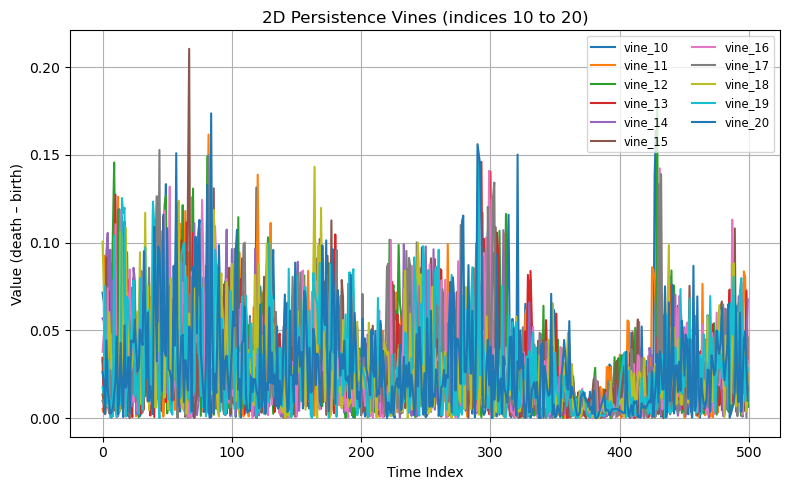

In [92]:
plot_vines_2d(scores_H1, start_idx=10, end_idx=20)

In [97]:
plotly_vines_3d(vines_H1, start_idx=5, end_idx=5)

In [99]:
plotly_vines_3d(vines_H1, start_idx=100, end_idx=100)